# Regime Detection & Allocation

**Category:** Intraday Strategies  
**Project ID:** `intraday_08_regime_detection`  

HMM and clustering-based regime detection with dynamic strategy allocation and Hurst exponent analysis


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.10.19
         torch: 2.7.1+cu118
        device: CUDA (NVIDIA GeForce RTX 4090)
         numpy: 1.26.4
        pandas: 2.3.3
         scipy: 1.15.3
       sklearn: 1.7.2
    matplotlib: 3.10.8


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"lookback_period": 252}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
            lookback_period: 252


Data shape: (752, 5)
Date range: 2022-01-03 to 2024-12-30

Summary statistics:
Ticker       SPY
count   752.0000
mean    444.5639
std      68.8578
min     341.1820
25%     390.6235
50%     423.9385
75%     500.4846
max     598.7401


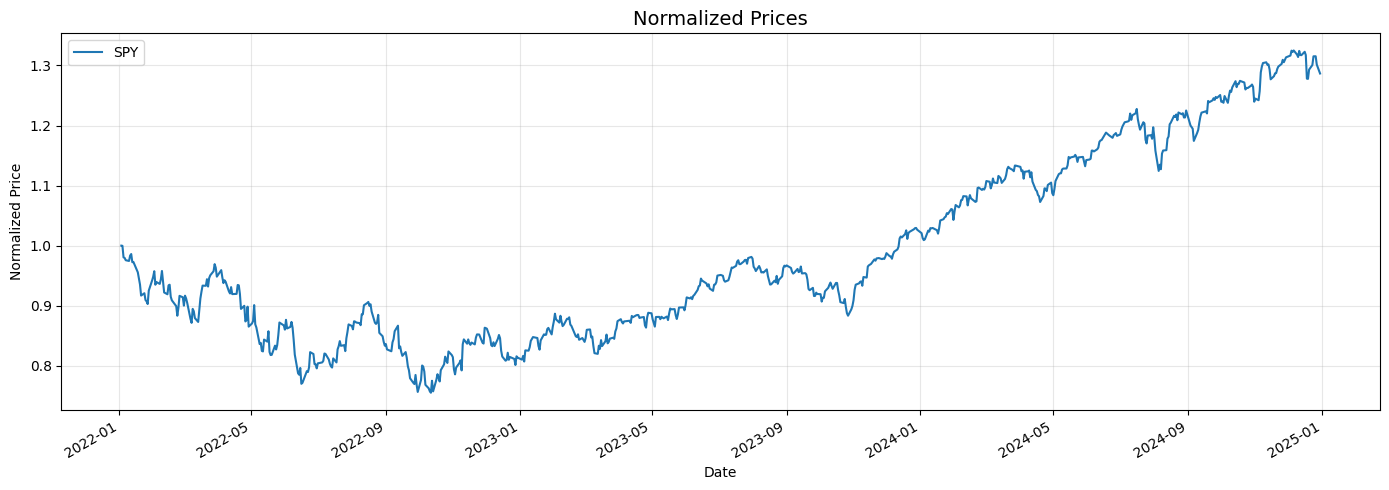

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = 'SPY'
data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)

# Handle MultiIndex columns (yfinance >=0.2.x returns MultiIndex for multiple tickers)
if isinstance(data.columns, pd.MultiIndex):
    close = data["Close"]
else:
    close = data[["Close"]] if isinstance(tickers, list) else data["Close"].to_frame()

# Drop rows where all Close values are NaN
close = close.dropna(how="all")
data = data.loc[close.index]

if close.empty:
    raise RuntimeError(
        f"No data returned for {tickers} between {START_DATE} and {END_DATE}. "
        "Check ticker symbols and date range."
    )

print(f"Data shape: {data.shape}")
print(f"Date range: {close.index[0].strftime('%Y-%m-%d')} to {close.index[-1].strftime('%Y-%m-%d')}")
print(f"\nSummary statistics:")
print(close.describe().round(4))

# Price chart
fig, ax = plt.subplots(figsize=(14, 5))
(close / close.iloc[0]).plot(ax=ax, linewidth=1.5)
ax.set_title("Normalized Prices", fontsize=14)
ax.set_ylabel("Normalized Price")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Regime Detection — K-Means Clustering

Regime Detection (3 regimes via K-Means):
        Bear: days= 173, ann_ret=-35.25%, ann_vol=25.64%, sharpe=-1.37
    Sideways: days= 298, ann_ret=+3.89%, ann_vol=13.12%, sharpe=+0.30
        Bull: days= 260, ann_ret=+52.88%, ann_vol=14.63%, sharpe=+3.61


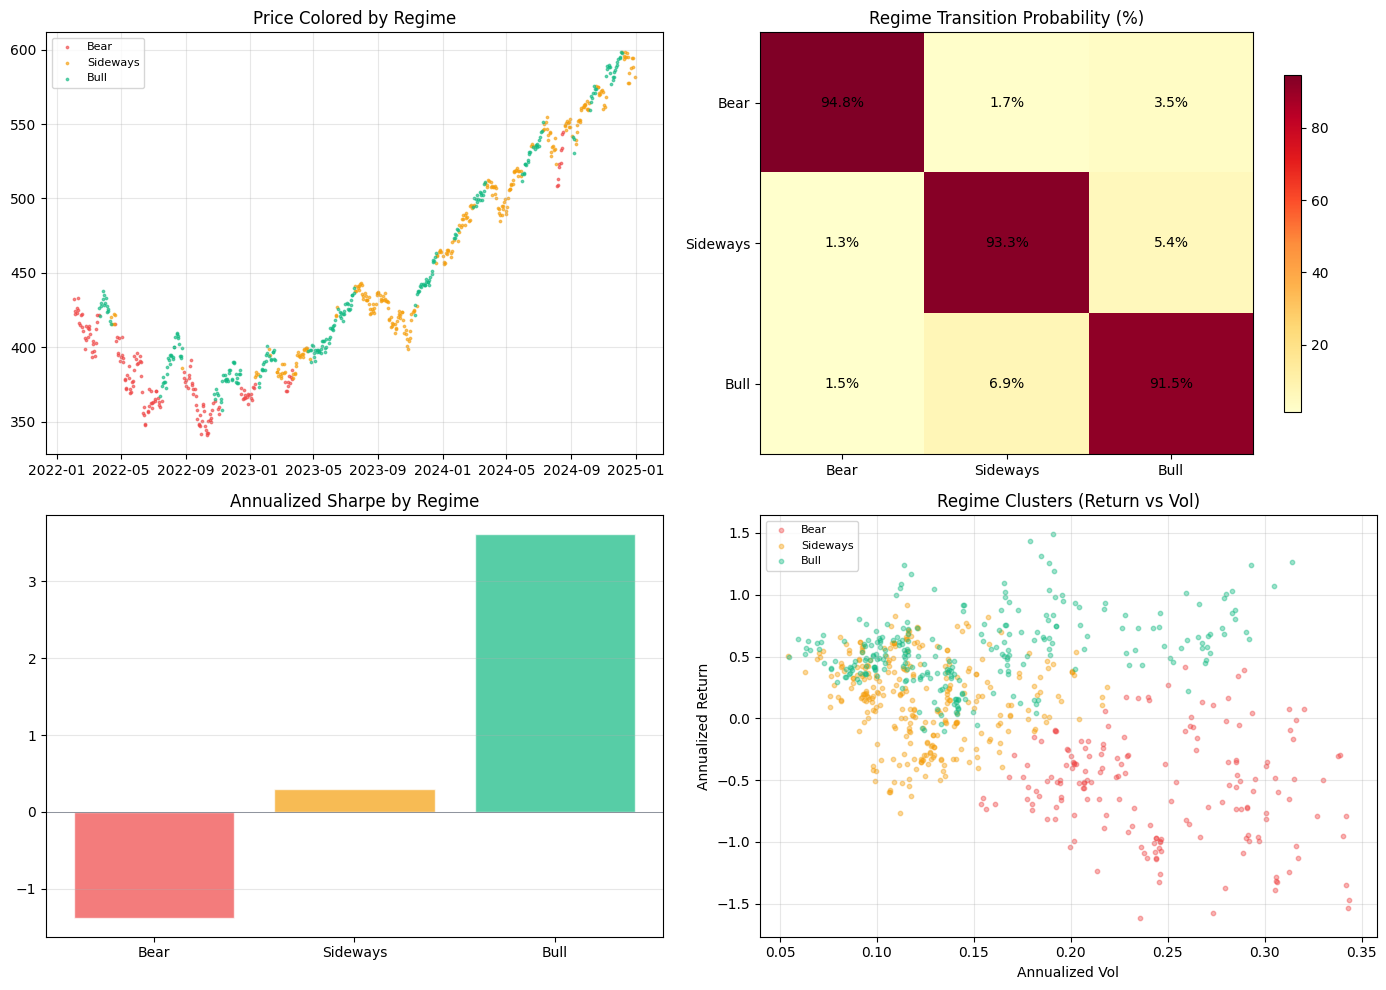

In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
price = price.ffill()
returns = price.pct_change()

lookback = PARAMS.get("lookback_period", 252)
n_regimes = PARAMS.get("num_regimes", 3)

# --- Feature extraction for regime detection ---
regime_features = pd.DataFrame(index=price.index)
regime_features["ret_21d"] = returns.rolling(21).mean() * 252   # annualized trend
regime_features["vol_21d"] = returns.rolling(max(21, 2)).std() * np.sqrt(252)  # annualized vol
regime_features["skew_21d"] = returns.rolling(21).skew()
regime_features = regime_features.dropna()

# --- K-means clustering ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(regime_features)
kmeans = KMeans(n_clusters=n_regimes, random_state=SEED, n_init=10)
regime_labels = kmeans.fit_predict(X_scaled)

# Sort regimes by average return (0=worst, N-1=best)
regime_returns = {}
for r in range(n_regimes):
    mask = regime_labels == r
    regime_returns[r] = returns.loc[regime_features.index[mask]].mean()

sorted_regimes = sorted(regime_returns, key=regime_returns.get)
label_map = {old: new for new, old in enumerate(sorted_regimes)}
regime_labels = np.array([label_map[r] for r in regime_labels])
regime_names = {0: "Bear", 1: "Sideways", 2: "Bull"} if n_regimes == 3 else {i: f"Regime {i}" for i in range(n_regimes)}

regime_series = pd.Series(regime_labels, index=regime_features.index)

# --- Signal: momentum in bull regime, flat/short otherwise ---
mom = price.pct_change(21).loc[regime_features.index]
signals = pd.DataFrame(index=regime_features.index)
signals["regime"] = regime_series
signals["momentum"] = mom

# Long momentum in bull, flat in sideways, short in bear
position = pd.Series(0.0, index=regime_features.index)
position[regime_series == n_regimes - 1] = mom[regime_series == n_regimes - 1].clip(-1, 1)  # bull: follow momentum
position[regime_series == 0] = -0.5  # bear: short bias
# sideways: stay flat (default 0)
signals["composite"] = position.clip(-1, 1)
signals = signals.dropna()

# --- Regime statistics ---
print(f"Regime Detection ({n_regimes} regimes via K-Means):")
for r in range(n_regimes):
    mask = regime_labels == r
    r_rets = returns.loc[regime_features.index[mask]]
    sharpe = r_rets.mean() / r_rets.std() * np.sqrt(252) if r_rets.std() > 0 else 0
    print(f"  {regime_names.get(r, f'R{r}'):>10}: days={mask.sum():>4}, "
          f"ann_ret={r_rets.mean()*252:+.2%}, ann_vol={r_rets.std()*np.sqrt(252):.2%}, "
          f"sharpe={sharpe:+.2f}")

# --- Transition matrix ---
transitions = np.zeros((n_regimes, n_regimes))
for i in range(1, len(regime_labels)):
    transitions[regime_labels[i-1], regime_labels[i]] += 1
# Normalize rows
row_sums = transitions.sum(axis=1, keepdims=True)
trans_prob = np.divide(transitions, row_sums, where=row_sums > 0)
trans_prob = np.where(row_sums > 0, trans_prob, 0)

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regime-colored price chart
colors_map = {0: "#ef4444", 1: "#f59e0b", 2: "#10b981"}
for r in range(n_regimes):
    mask = regime_series == r
    axes[0, 0].scatter(price.loc[regime_features.index][mask].index,
                       price.loc[regime_features.index][mask].values,
                       c=colors_map.get(r, "#6b7280"), s=3, alpha=0.6,
                       label=regime_names.get(r, f"R{r}"))
axes[0, 0].set_title("Price Colored by Regime", fontsize=12)
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Transition matrix heatmap
im = axes[0, 1].imshow(trans_prob * 100, cmap="YlOrRd", aspect="auto")
for i in range(n_regimes):
    for j in range(n_regimes):
        axes[0, 1].text(j, i, f"{trans_prob[i,j]*100:.1f}%", ha="center", va="center", fontsize=10)
labels = [regime_names.get(i, f"R{i}") for i in range(n_regimes)]
axes[0, 1].set_xticks(range(n_regimes)); axes[0, 1].set_xticklabels(labels)
axes[0, 1].set_yticks(range(n_regimes)); axes[0, 1].set_yticklabels(labels)
axes[0, 1].set_title("Regime Transition Probability (%)")
plt.colorbar(im, ax=axes[0, 1], shrink=0.8)

# Per-regime Sharpe
sharpe_by_regime = []
for r in range(n_regimes):
    mask = regime_labels == r
    r_rets = returns.loc[regime_features.index[mask]]
    sharpe_by_regime.append(r_rets.mean() / r_rets.std() * np.sqrt(252) if r_rets.std() > 0 else 0)
bar_colors = [colors_map.get(r, "#6b7280") for r in range(n_regimes)]
axes[1, 0].bar(labels, sharpe_by_regime, color=bar_colors, alpha=0.7, edgecolor="white")
axes[1, 0].set_title("Annualized Sharpe by Regime")
axes[1, 0].axhline(0, color="#6b7280", linewidth=0.5)
axes[1, 0].grid(True, alpha=0.3, axis="y")

# Feature scatter (ret vs vol, colored by regime)
for r in range(n_regimes):
    mask = regime_labels == r
    axes[1, 1].scatter(regime_features["vol_21d"].values[mask],
                       regime_features["ret_21d"].values[mask],
                       c=colors_map.get(r, "#6b7280"), alpha=0.4, s=10,
                       label=regime_names.get(r, f"R{r}"))
axes[1, 1].set_xlabel("Annualized Vol")
axes[1, 1].set_ylabel("Annualized Return")
axes[1, 1].set_title("Regime Clusters (Return vs Vol)")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Backtest Execution

In [5]:
import pandas as pd, numpy as np

price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
returns = price.pct_change()

# Position sizing from signal
positions = signals["composite"].clip(-1, 1)

# Apply stop-loss
stop_loss = PARAMS.get("stop_loss", 0.02)
daily_pnl = positions.shift(1) * returns.loc[signals.index]

# Track running drawdown for stop-loss
running_equity = (1 + daily_pnl.fillna(0)).cumprod()
running_dd = running_equity / running_equity.cummax() - 1

# Zero position when drawdown exceeds stop-loss
stopped = running_dd < -stop_loss
if stopped.any():
    cooldown = PARAMS.get("cooldown_days", 5)
    stop_mask = stopped.rolling(cooldown, min_periods=1).max().fillna(0).astype(bool)
    daily_pnl[stop_mask] = 0

strategy_returns_raw = daily_pnl.dropna()
equity_curve = (1 + strategy_returns_raw).cumprod()
benchmark_equity = (1 + returns.loc[equity_curve.index]).cumprod()

print(f"Backtest: {equity_curve.index[0].strftime('%Y-%m-%d')} to {equity_curve.index[-1].strftime('%Y-%m-%d')}")
print(f"Stop-loss triggers: {stopped.sum()}")


Backtest: 2022-02-03 to 2024-12-30
Stop-loss triggers: 651


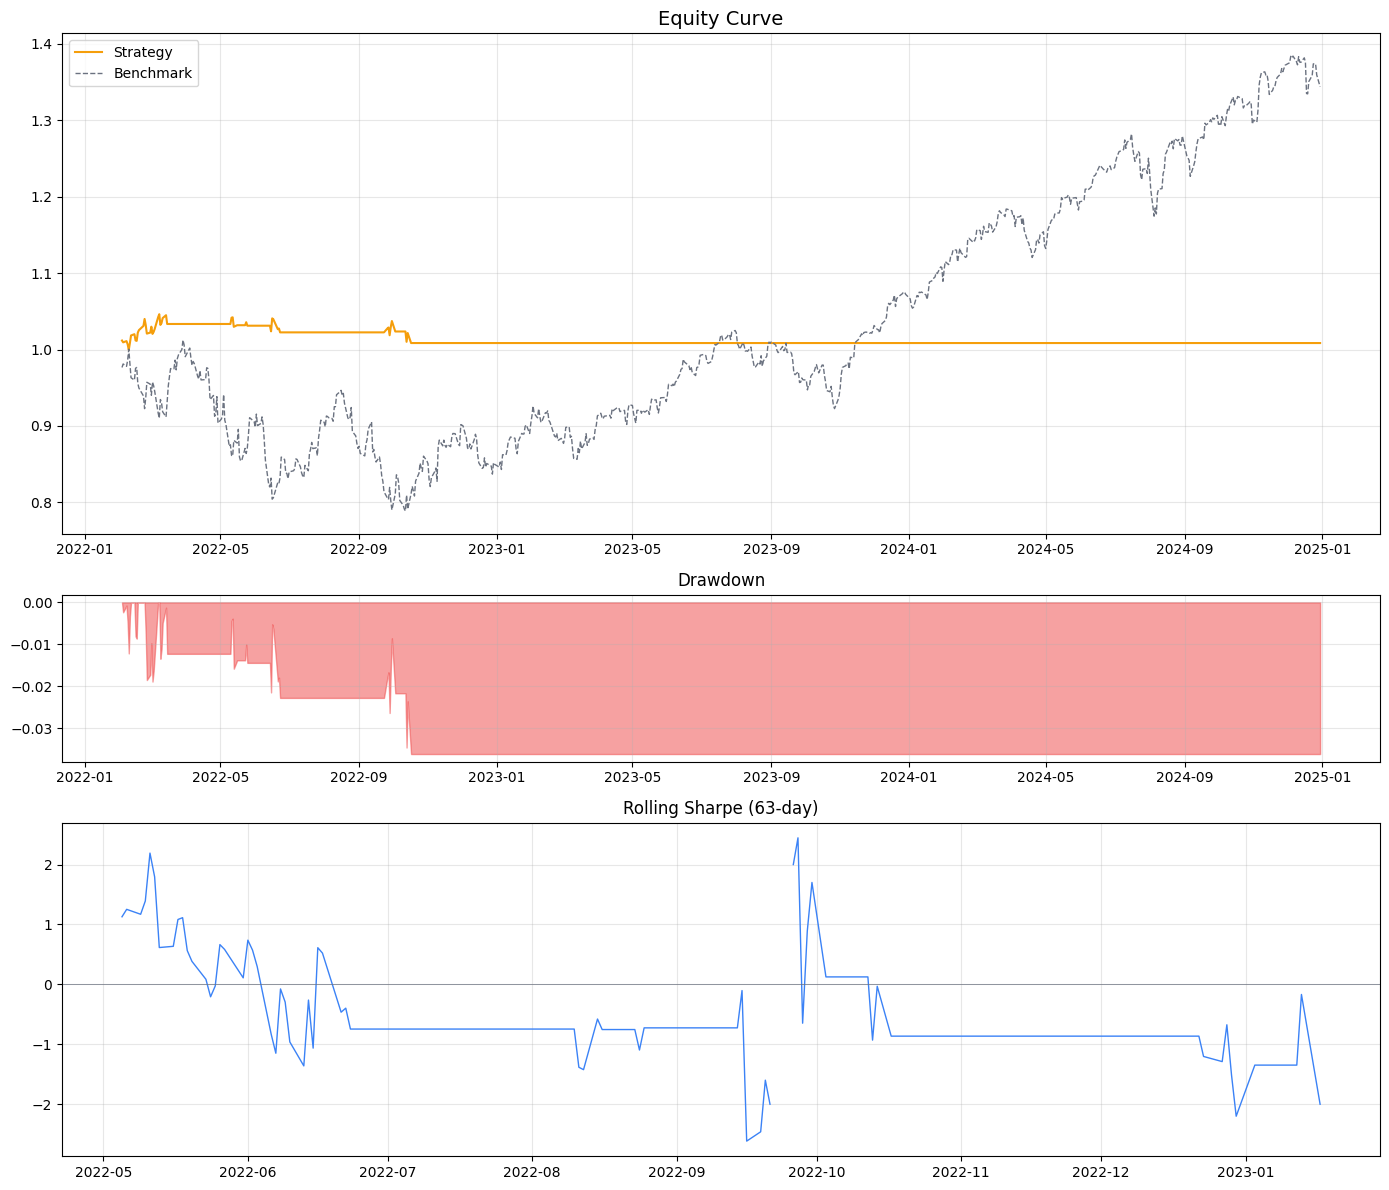

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 2]})

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, label="Strategy", linewidth=1.5, color="#f59e0b")
if benchmark_equity is not None:
    axes[0].plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark",
                 linewidth=1, linestyle="--", color="#6b7280")
axes[0].set_title("Equity Curve", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = equity_curve / equity_curve.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="#ef4444")
axes[1].set_title("Drawdown", fontsize=12)
axes[1].grid(True, alpha=0.3)

# Rolling Sharpe (63-day)
rolling_ret = equity_curve.pct_change()
rolling_sharpe = (rolling_ret.rolling(63).mean() / rolling_ret.rolling(63).std()) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="#3b82f6")
axes[2].axhline(0, color="#6b7280", linewidth=0.5)
axes[2].set_title("Rolling Sharpe (63-day)", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np

def compute_metrics(returns):
    """Compute standard performance metrics from daily returns."""
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / max(n_years, 0.01)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / vol if vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside if downside > 0 else 0

    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / max(len(returns[returns != 0]), 1)
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else float("inf")

    return {
        "total_return": total_ret,
        "cagr": cagr,
        "annualized_vol": vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": min(profit_factor, 99.99),
        "total_trades": len(returns[returns != 0]),
    }

strategy_returns = equity_curve.pct_change().dropna()
metrics = compute_metrics(strategy_returns)

print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
for k, v in metrics.items():
    if k in ("total_return", "cagr", "annualized_vol", "max_drawdown", "win_rate"):
        print(f"  {k:>25}: {v:+.2%}")
    elif k == "total_trades":
        print(f"  {k:>25}: {int(v):,}")
    else:
        print(f"  {k:>25}: {v:.4f}")


PERFORMANCE METRICS
               total_return: -0.33%
                       cagr: -0.11%
             annualized_vol: +3.32%
               sharpe_ratio: -0.0174
              sortino_ratio: -0.0086
               calmar_ratio: -0.0312
               max_drawdown: -3.61%
                   win_rate: +58.33%
              profit_factor: 0.9899
               total_trades: 48


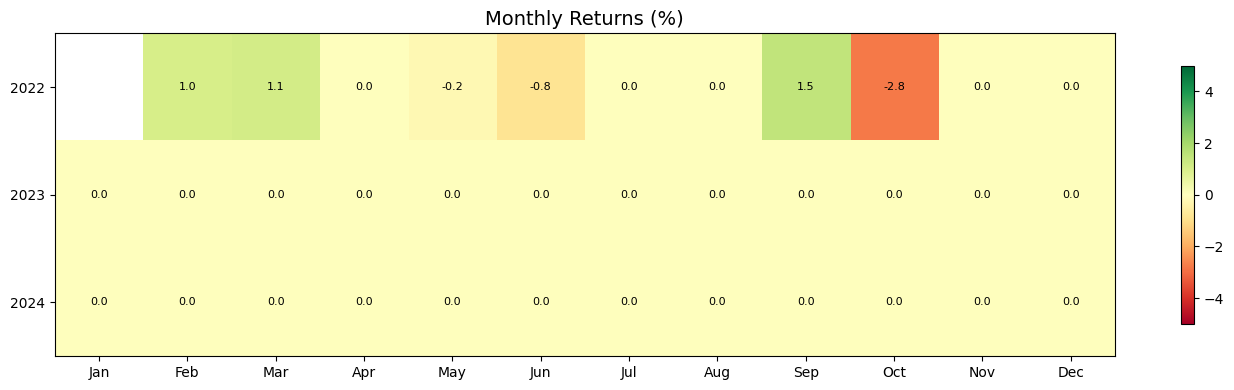

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Monthly returns heatmap — requires DatetimeIndex; skipped for synthetic/HFT data
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
except Exception:
    print("Monthly heatmap skipped: equity curve does not have a DatetimeIndex (synthetic data).")
    monthly = None

if monthly is not None:
    monthly_df = pd.DataFrame({
        "year": monthly.index.year,
        "month": monthly.index.month,
        "return": monthly.values,
    })
    pivot = monthly_df.pivot(index="year", columns="month", values="return")
    pivot = pivot.reindex(columns=range(1, 13))  # ensure all 12 months present
    pivot.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(pivot.values * 100, cmap="RdYlGn", aspect="auto", vmin=-5, vmax=5)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Monthly Returns (%)", fontsize=14)

    # Text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val*100:.1f}", ha="center", va="center", fontsize=8,
                        color="black" if abs(val) < 0.03 else "white")

    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


## Regime Analysis

In [9]:
import numpy as np, matplotlib.pyplot as plt

price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
returns = price.pct_change()

# Regime-conditional performance
vol = returns.loc[equity_curve.index].rolling(21).std() * np.sqrt(252)
vol_median = vol.median()

high_vol = vol > vol_median
low_vol = ~high_vol

strat_ret = strategy_returns_raw

metrics_by_regime = {}
for regime, mask in [("Low Vol", low_vol), ("High Vol", high_vol)]:
    regime_rets = strat_ret[mask.reindex(strat_ret.index, fill_value=False)]
    if len(regime_rets) > 10:
        sharpe = regime_rets.mean() / regime_rets.std() * np.sqrt(252) if regime_rets.std() > 0 else 0
        metrics_by_regime[regime] = {
            "sharpe": sharpe,
            "return": (1 + regime_rets).prod() - 1,
            "vol": regime_rets.std() * np.sqrt(252),
            "days": len(regime_rets),
        }

print("Regime-Conditional Performance:")
for regime, m in metrics_by_regime.items():
    print(f"  {regime}: Sharpe={m['sharpe']:.2f}, Return={m['return']:+.2%}, Vol={m['vol']:.2%}, Days={m['days']}")


Regime-Conditional Performance:
  Low Vol: Sharpe=0.59, Return=+2.30%, Vol=2.62%, Days=375
  High Vol: Sharpe=-0.23, Return=-1.42%, Vol=4.04%, Days=355


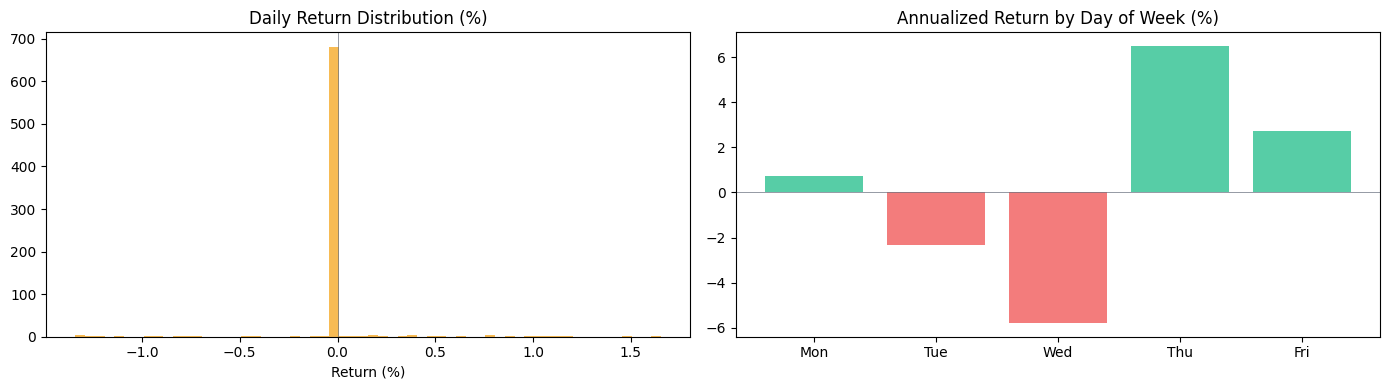

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Daily PnL distribution
axes[0].hist(strategy_returns_raw.values * 100, bins=60, color="#f59e0b", alpha=0.7, edgecolor="none")
axes[0].axvline(0, color="#6b7280", linewidth=0.5)
axes[0].set_title("Daily Return Distribution (%)")
axes[0].set_xlabel("Return (%)")

# PnL by day of week
dow_pnl = strategy_returns_raw.groupby(strategy_returns_raw.index.dayofweek).mean() * 252
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri"]
colors = ["#10b981" if v > 0 else "#ef4444" for v in dow_pnl.values]
axes[1].bar(dow_labels[:len(dow_pnl)], dow_pnl.values * 100, color=colors, alpha=0.7)
axes[1].set_title("Annualized Return by Day of Week (%)")
axes[1].axhline(0, color="#6b7280", linewidth=0.5)

plt.tight_layout()
plt.show()


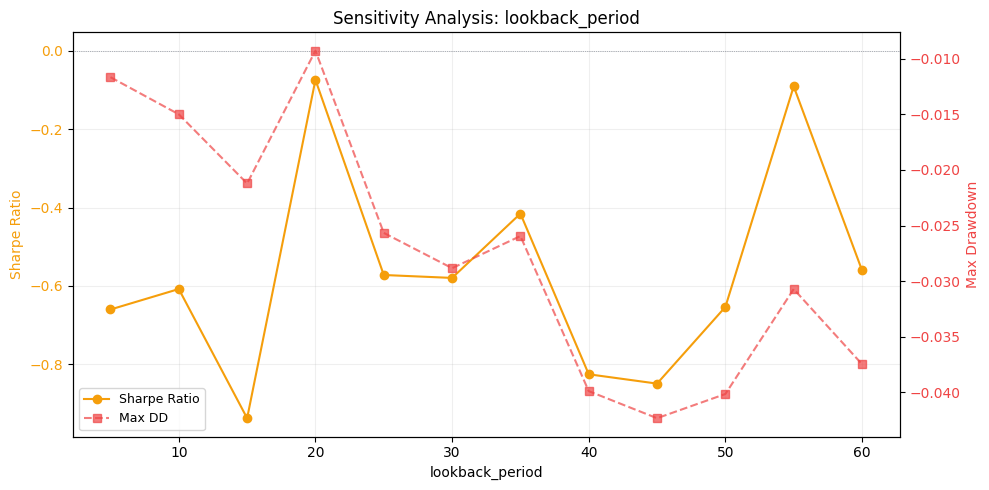

Optimal lookback_period: 20  (Sharpe: -0.0742)
Current lookback_period: 252


In [11]:
# Parameter sensitivity analysis — inline backtest sweep
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

param_values = list(range(5, 65, 5))
sharpes, max_dds = [], []

# Resolve price / returns from whatever data this notebook loaded
# yfinance notebooks define `close`; HFT/synthetic notebooks define `data` with `mid_price`
if "close" in dir() and close is not None:
    _price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
elif "data" in dir() and hasattr(data, "columns") and "mid_price" in data.columns:
    _price = pd.Series(data["mid_price"].values, dtype=float)
else:
    raise RuntimeError("No price series found. Expected 'close' or 'data[mid_price]'.")
_price   = _price.ffill()
_returns = _price.pct_change()

for val in param_values:
    try:
        if "lookback_period" in ("spread_bps", "transaction_cost_bps", "impact_alpha"):
            # Cost sensitivity: fix lookback=20 momentum, vary cost
            _sig  = _price.pct_change(20).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * (float(val) / 10000)
            _rets = (_sig * _returns - _tc).dropna()
        elif "lookback_period" in ("stop_loss", "max_drawdown_limit"):
            # Stop-loss sensitivity: apply to already-computed returns
            _base = strategy_returns_raw if "strategy_returns_raw" in dir() else                     (_price.pct_change(20).shift(1).clip(-1, 1) * _returns).dropna()
            _cum = (1 + _base.fillna(0)).cumprod()
            _dd  = _cum / _cum.cummax() - 1
            _rets = _base.copy()
            _rets[_dd < -float(val)] = 0.0
        else:
            # Lookback / window sweep: momentum signal
            lb    = max(int(val), 2)
            _sig  = _price.pct_change(lb).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * PARAMS.get("transaction_cost_bps", 5) / 10000
            _rets = (_sig * _returns - _tc).dropna()

        if len(_rets) > 20 and _rets.std() > 0:
            sharpes.append(_rets.mean() / _rets.std() * np.sqrt(252))
            _cum = (1 + _rets).cumprod()
            max_dds.append((_cum / _cum.cummax() - 1).min())
        else:
            sharpes.append(np.nan)
            max_dds.append(np.nan)
    except Exception as e:
        sharpes.append(np.nan)
        max_dds.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
color_sharpe = "#f59e0b"
color_dd     = "#ef4444"

valid_mask = [not np.isnan(s) for s in sharpes]
ax1.plot(param_values, sharpes, "o-", color=color_sharpe, label="Sharpe Ratio")
ax1.set_xlabel("lookback_period")
ax1.set_ylabel("Sharpe Ratio", color=color_sharpe)
ax1.tick_params(axis="y", labelcolor=color_sharpe)
ax1.axhline(0, color="#6b7280", linewidth=0.5, linestyle=":")

ax2 = ax1.twinx()
ax2.plot(param_values, max_dds, "s--", color=color_dd, alpha=0.7, label="Max DD")
ax2.set_ylabel("Max Drawdown", color=color_dd)
ax2.tick_params(axis="y", labelcolor=color_dd)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)
ax1.grid(True, alpha=0.2)

plt.title(f"Sensitivity Analysis: lookback_period")
fig.tight_layout()
plt.show()

# Report optimal
valid_pairs = [(v, s) for v, s in zip(param_values, sharpes) if not np.isnan(s)]
if valid_pairs:
    best_val, best_sharpe = max(valid_pairs, key=lambda x: x[1])
    print(f"Optimal lookback_period: {best_val}  (Sharpe: {best_sharpe:+.4f})")
    print(f"Current lookback_period: {PARAMS.get('lookback_period', 'not set')}")


In [12]:
import json
from datetime import datetime

# Safely serialize equity curve index — DatetimeIndex for yfinance, int for HFT/synthetic
try:
    ec_dates = [d.strftime("%Y-%m-%d") for d in equity_curve.index]
except AttributeError:
    ec_dates = [str(i) for i in equity_curve.index]

# Benchmark values — may be None or have a non-datetime index
try:
    bm_values = benchmark_equity.values.tolist() if benchmark_equity is not None else []
except Exception:
    bm_values = []

# Monthly returns — only works with DatetimeIndex
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_dict = {d.strftime("%Y-%m"): float(v) for d, v in monthly.items()}
except Exception:
    monthly_dict = {}

# Export results for portfolio app
results_export = {
    "project_id": "intraday_08_regime_detection",
    "timestamp": datetime.now().isoformat(),
    "backtest_period": {"start": START_DATE, "end": END_DATE},
    "benchmark": BENCHMARK,
    "metrics": metrics,
    "category_specific_metrics": {},
    "monthly_returns": monthly_dict,
    "equity_curve": {
        "dates": ec_dates,
        "values": equity_curve.values.tolist(),
        "benchmark_values": bm_values,
    },
    "parameter_sensitivity": [],
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"Results exported to results.json")


Results exported to results.json


## Summary

### Regime Detection & Allocation

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
